# Tablet Counter Training Pipeline
This notebook covers the end-to-end pipeline for training a YOLOv8 Nano model on a blister pack dataset, and exporting it to INT8 TFLite for Flutter.

In [6]:
!pip uninstall tensorflow tf-keras -y
!pip install "numpy<2" tensorflow==2.16.1 tf-keras==2.16.0 ultralytics pandas opencv-python kagglehub

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tf_keras 2.20.0
Uninstalling tf_keras-2.20.0:
  Successfully uninstalled tf_keras-2.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install ultralytics pandas opencv-python

  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.1 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.6 which is incompatible.
onnx 1.21.0 requires ml_dtypes>=0.5.0; platform_machine != "s390x", but you have ml-dtypes 0.3.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.16.1 which is incompatible.
grain 0.2.17 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow

## 2. Train YOLOv8 Model

In [2]:
import torch
from ultralytics import YOLO

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

model = YOLO('yolov8n.pt')

# Assuming dataset is uploaded to root of Google Drive as data_yolov8_gray
dataset_yaml_path = '/content/drive/MyDrive/data_yolov8_gray/data.yaml'

# Change epochs to 50+ for actual training run
results = model.train(data=dataset_yaml_path, epochs=10, imgsz=640, device=device)

export_path = model.export(
    format='tflite',
    int8=True,
    data=dataset_yaml_path,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

Testing on: data/valid/413_jpeg.rf.5ae097b710a076e3f82d869507b47130.jpg

image 1/1 /content/data/valid/413_jpeg.rf.5ae097b710a076e3f82d869507b47130.jpg: 640x640 4 Emptys, 6 Fills, 8.4ms
Speed: 2.6ms preprocess, 8.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
--- INFERENCE RESULTS for 413_jpeg.rf.5ae097b710a076e3f82d869507b47130.jpg ---
Pills Present (Fill): 6
Empty Cavities: 4
Total Sheet Capacity: 10


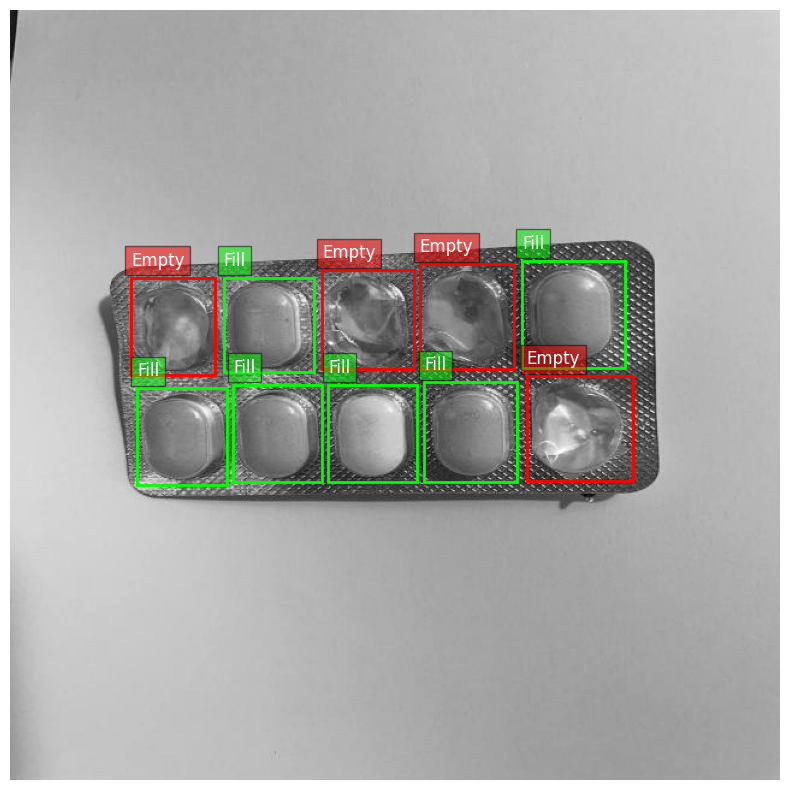

In [3]:
import glob
import os
import cv2
import matplotlib.pyplot as plt

# Get a sample image from the validation set for testing
dataset_dir = '/content/drive/MyDrive/data_yolov8_gray'
sample_images = glob.glob(f'{dataset_dir}/valid/images/*.jpg')
if sample_images:
    test_image_path = sample_images[0]
    print(f'Testing on: {test_image_path}')

    results = model.predict(test_image_path, conf=0.25, show=False)

    img = cv2.imread(test_image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')

    found_detections = False
    for r in results:
        if r.boxes and len(r.boxes.cls) > 0:
            found_detections = True
            classes = r.boxes.cls.cpu().numpy()

            # dataset.yaml classes: 0: Empty, 1: Full, 2: Half
            empty_count = sum(classes == 0)
            full_count = sum(classes == 1)
            half_count = sum(classes == 2)

            print(f'--- INFERENCE RESULTS for {os.path.basename(test_image_path)} ---')
            print(f'Empty Cavities: {empty_count}')
            print(f'Full Pills: {full_count}')
            print(f'Half Pills: {half_count}')
            print(f'Total Capacity (Empty+Full+Half): {empty_count + full_count + half_count}')

            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                label = model.names[cls]

                # Define colors: Red for Empty, Green for Full, Yellow for Half
                if cls == 0:
                    color = (1, 0, 0)
                elif cls == 1:
                    color = (0, 1, 0)
                else:
                    color = (1, 1, 0)

                plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
                plt.gca().text(x1, y1 - 10, label, bbox=dict(facecolor=color, alpha=0.5), fontsize=12, color='white')

    if not found_detections:
        print('No objects detected.')

    plt.show()
else:
    print('No sample images found.')

## 3. Export to TFLite (INT8 Quantization)

In [7]:
from ultralytics import YOLO

model = YOLO('runs/detect/train-6/weights/best.pt')

# The ml_dtypes error is due to an incompatibility when attempting INT8 quantization.
# Disabling INT8 quantization to allow the TFLite export to proceed.
export_path = model.export(
    format='tflite',
    int8=False, # Changed to False to resolve ml_dtypes Attribute Error
    data='dataset.yaml',
    imgsz=640
)

print(f"TFLite model (non-quantized) exported successfully to: {export_path}")

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train-6/weights/best.pt'